In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv(r"C:\Users\Martino VIGNIGBE\OneDrive\DATA SCIENCE PROJECT MARTINO\sales-analytics\data\sales_analytics_dataset.csv")

df.head()

,Order_ID,Order_Date,Customer_ID,Category,Product,Region,City,Quantity,Unit_Price,Discount,Sales,Cost,Profit,Payment_Method,Customer_Segment
0,ORD-03777,2025-01-01,CUST-0815,Furniture,Desk,West,Ahmedabad,7,176.10,0.05,1171.06,997.19,173.87,UPI,Small Business
1,ORD-03451,2025-01-01,CUST-0670,Office Supplies,Notebook,Central,Nagpur,7,36.04,0.10,227.05,170.12,56.93,Bank Transfer,Small Business
2,ORD-03201,2025-01-01,CUST-0669,Home & Kitchen,Vacuum Cleaner,North,Delhi,2,170.59,0.05,324.12,249.45,74.67,UPI,Small Business
3,ORD-00749,2025-01-01,CUST-0396,Office Supplies,Pen Set,North,Chandigarh,1,41.93,0.00,41.93,25.66,16.27,Bank Transfer,Consumer
4,ORD-04491,2025-01-01,CUST-0472,Furniture,Table,South,Bengaluru,2,284.65,0.05,540.83,373.17,167.66,Debit Card,Corporate


In [3]:
df.shape

(5000, 15)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          5000 non-null   object 
 1   Order_Date        5000 non-null   object 
 2   Customer_ID       5000 non-null   object 
 3   Category          5000 non-null   object 
 4   Product           5000 non-null   object 
 5   Region            5000 non-null   object 
 6   City              5000 non-null   object 
 7   Quantity          5000 non-null   int64  
 8   Unit_Price        5000 non-null   float64
 9   Discount          5000 non-null   float64
 10  Sales             5000 non-null   float64
 11  Cost              5000 non-null   float64
 12  Profit            5000 non-null   float64
 13  Payment_Method    5000 non-null   object 
 14  Customer_Segment  5000 non-null   object 
dtypes: float64(5), int64(1), object(9)
memory usage: 586.1+ KB


In [5]:
df.describe()

,Quantity,Unit_Price,Discount,Sales,Cost,Profit
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,4.548000,198.724002,0.063540,849.932892,608.490462,241.442430
std,2.284631,180.038905,0.060708,962.518548,693.869552,294.395812
min,1.000000,6.110000,0.000000,7.950000,5.200000,2.130000
25%,3.000000,46.647500,0.000000,184.785000,129.230000,47.612500
50%,5.000000,118.635000,0.050000,412.730000,297.525000,114.140000
75%,7.000000,337.642500,0.100000,1236.285000,876.462500,328.025000
max,8.000000,889.060000,0.200000,5522.160000,4367.510000,2109.180000


Data Cleaning

In [6]:
df.isnull().sum()

Order_ID            0
Order_Date          0
Customer_ID         0
Category            0
Product             0
Region              0
City                0
Quantity            0
Unit_Price          0
Discount            0
Sales               0
Cost                0
Profit              0
Payment_Method      0
Customer_Segment    0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.dtypes

Order_ID             object
Order_Date           object
Customer_ID          object
Category             object
Product              object
Region               object
City                 object
Quantity              int64
Unit_Price          float64
Discount            float64
Sales               float64
Cost                float64
Profit              float64
Payment_Method       object
Customer_Segment     object
dtype: object

In [9]:
#convertir la colonne de date en format de date 

df["Order_Date"] = pd.to_datetime(df["Order_Date"])

Feature Engineering

-creer de nouvelles variables 

In [10]:
df["Revenue"] = df["Quantity"] * df["Unit_Price"]

In [11]:
df["Profit"] = df["Revenue"] - df["Cost"]

In [12]:
df["Profit_Margin"] = (df["Profit"] / df["Revenue"]) * 100

In [13]:
df["Month"] = df["Order_Date"].dt.month

In [14]:
df["Year"] = df["Order_Date"].dt.year

In [26]:
df.head(20)

,Order_ID,Order_Date,Customer_ID,Category,Product,Region,City,Quantity,Unit_Price,Discount,Sales,Cost,Profit,Payment_Method,Customer_Segment,Revenue,Profit_Margin,Month,Year
0,ORD-03777,2025-01-01,CUST-0815,Furniture,Desk,West,Ahmedabad,7,176.10,0.05,1171.06,997.19,235.51,UPI,Small Business,1232.70,19.105216,1,2025
1,ORD-03451,2025-01-01,CUST-0670,Office Supplies,Notebook,Central,Nagpur,7,36.04,0.10,227.05,170.12,82.16,Bank Transfer,Small Business,252.28,32.566989,1,2025
2,ORD-03201,2025-01-01,CUST-0669,Home & Kitchen,Vacuum Cleaner,North,Delhi,2,170.59,0.05,324.12,249.45,91.73,UPI,Small Business,341.18,26.886101,1,2025
3,ORD-00749,2025-01-01,CUST-0396,Office Supplies,Pen Set,North,Chandigarh,1,41.93,0.00,41.93,25.66,16.27,Bank Transfer,Consumer,41.93,38.802767,1,2025
4,ORD-04491,2025-01-01,CUST-0472,Furniture,Table,South,Bengaluru,2,284.65,0.05,540.83,373.17,196.13,Debit Card,Corporate,569.30,34.451080,1,2025
5,ORD-01098,2025-01-01,CUST-0806,Office Supplies,Printer Paper,East,Bhubaneswar,6,46.48,0.05,264.94,199.19,79.69,Cash,Small Business,278.88,28.575014,1,2025
6,ORD-01134,2025-01-01,CUST-0173,Furniture,Desk,South,Bengaluru,3,346.62,0.00,1039.86,680.06,359.80,Credit Card,Consumer,1039.86,34.600812,1,2025
7,ORD-04215,2025-01-01,CUST-0522,Electronics,Laptop,Central,Bhopal,1,459.71,0.05,436.72,265.89,193.82,Cash,Small Business,459.71,42.161363,1,2025
8,ORD-03600,2025-01-01,CUST-0760,Office Supplies,Stapler,West,Ahmedabad,1,47.48,0.05,45.11,33.59,13.89,Bank Transfer,Corporate,47.48,29.254423,1,2025
9,ORD-01316,2025-01-01,CUST-0653,Electronics,Monitor,South,Hyderabad,5,406.94,0.10,1831.23,1443.01,591.69,Credit Card,Consumer,2034.70,29.079963,1,2025


EDA

In [16]:
df["Revenue"].sum()

np.float64(4533660.52)

In [17]:
df["Profit"].sum()

np.float64(1491208.21)

In [18]:
df["Quantity"].sum()

np.int64(22740)

In [19]:
df["Customer_ID"].nunique() # nbre total de clients 

1188

Quels sont les 10 produits qui génèrent le plus de revenus ?

In [20]:
top_products = (
    df.groupby("Product")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

print(top_products.head(10))

Product
Laptop          570961.76
Headphones      550883.62
Keyboard        544436.04
Monitor         505517.70
Smartphone      439142.65
Office Chair    212996.85
Table           210554.95
Bookshelf       207804.04
Cabinet         194026.37
Desk            191210.06
Name: Revenue, dtype: float64


Sales par catégorie

In [21]:
category_sales = (
    df.groupby("Category")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

print(category_sales)

Category
Electronics        2610941.77
Furniture          1016592.27
Home & Kitchen      467564.91
Clothing            249608.68
Office Supplies     188952.89
Name: Revenue, dtype: float64


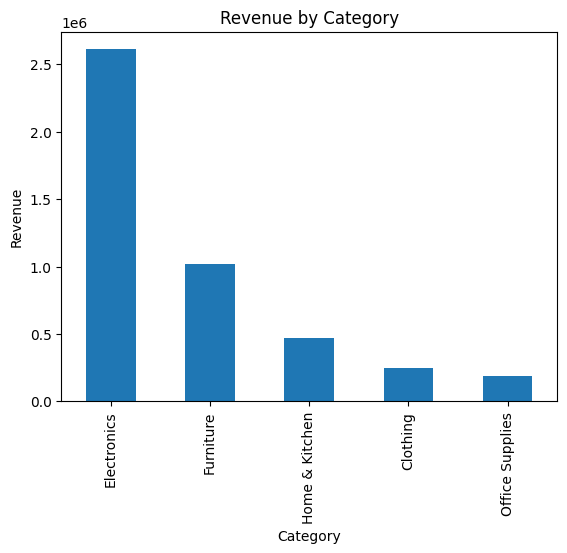

In [22]:
#Visualisation :

category_sales.plot(kind="bar")

plt.title("Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Revenue")

plt.show()

In [23]:
#Sales par région : Quelle région génère le plus de chiffre d'affaires ?

region_sales = (
    df.groupby("Region")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

print(region_sales)

Region
Central    955881.11
South      945376.81
East       902298.19
West       902008.28
North      828096.13
Name: Revenue, dtype: float64


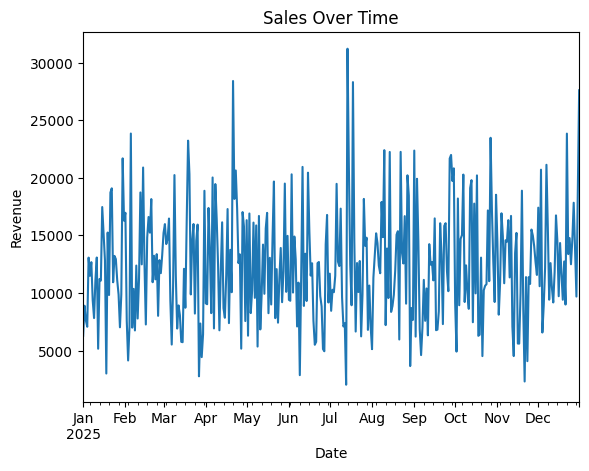

In [24]:
#Évolution des ventes
monthly_sales = (
    df.groupby("Order_Date")["Revenue"]
    .sum()
)

#visualisation
monthly_sales.plot()

plt.title("Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Revenue")

plt.show()

In [25]:
#Analyse du profit :Produit avec le plus de ventes ≠ forcément produit avec le plus de profit.
# C'est exactement le genre d'insight qu'un Data Analyst doit savoir identifier

profit_category = (
    df.groupby("Category")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

print(profit_category)


Category
Electronics        861606.37
Furniture          333302.68
Home & Kitchen     152827.77
Clothing            81506.71
Office Supplies     61964.68
Name: Profit, dtype: float64
